# Mentoría M10 - Práctico 2
## Análisis exploratorio, curación de datos e ingeniería ETL reproducible

**Proyecto:** SalarIA - clasificación de coberturas terrestres en ambientes salares mediante datos tabulares derivados de Sentinel-2.  
**Entrega:** 04/09 - Práctico 2.  
**Objetivo:** producir un dataset depurado, documentado, trazable y preparado para aprendizaje automático.

Esta notebook está pensada como plantilla robusta: puede ejecutarse localmente, en VS Code, JupyterLab o Google Colab. No modifica los CSV originales del repositorio; genera salidas nuevas en `data/processed/`, `data/quality/` y `data/warehouse/`.

## Qué mejora respecto del Práctico 1

En los notebooks de Análisis y Visualización se observaron fortalezas importantes:

- buena exploración de `pixels_raw -> pixels -> features`;
- comparación de clases por píxel y por polígono;
- análisis de histogramas, boxplots, correlaciones y firmas espectrales;
- atención al filtro `SCL`, al `sample_id`, a los splits y a la posible fuga de información;
- visualización espacial mediante `x`, `y` y polígonos cuando estaban disponibles.

Para el Práctico 2 se agregan piezas que suelen faltar en un trabajo de curación profesional:

1. **ETL reproducible** con SQLite + SQLAlchemy.
2. **Contratos de datos**: esquema esperado, tipos, dominios, rangos y consistencia de etiquetas.
3. **Métodos estadísticos** para nulos, outliers, redundancia, separabilidad y balance de clases.
4. **Ingeniería de features geoespaciales** a partir de coordenadas y, opcionalmente, geometrías.
5. **Registro de decisiones**: qué se detectó, qué se cambió, qué no se tocó y por qué.
6. **Dataset curado versionado** y listo para ML sin fuga de información.

## Cómo leer esta versión comentada

Esta versión conserva la lógica y las salidas del notebook original, pero agrega dos niveles de explicación:

1. **comentarios dentro del código**, para entender qué hace cada bloque y por qué;
2. **interpretación inmediatamente después de las salidas**, para entender qué significa el resultado y qué decisión metodológica se desprende.

> **Importante:** en análisis de datos, una salida estadística no es una orden automática de limpieza. Un outlier puede ser físicamente válido, un p-value pequeño no mide importancia práctica y una correlación alta no obliga a eliminar una variable. En este notebook se separa deliberadamente **detectar**, **interpretar** y **decidir**.


In [1]:
# 0. Instalación opcional de dependencias
# Esta celda NO instala nada por defecto porque la línea está comentada.
# En Google Colab o en un entorno nuevo, quitar el "#" inicial para instalar
# las bibliotecas que requiere el notebook.
#
# tabulate es necesaria para DataFrame.to_markdown(), usado en el reporte final.
# pyarrow permite guardar el dataset en formato Parquet.
# geopandas + shapely permiten trabajar con el GeoJSON y calcular geometrías.
#
# !pip install -q sqlalchemy pyarrow openpyxl scipy scikit-learn statsmodels geopandas shapely tabulate


### Explicación de la etapa 0

Esta celda deja preparado el entorno. Está comentada deliberadamente para no instalar paquetes cada vez que se abre el notebook. En un entorno limpio, `tabulate` es especialmente importante porque `DataFrame.to_markdown()` lo utiliza al generar el reporte final.

**Idea de ingeniería:** las dependencias deberían terminar en un `requirements.txt` o `environment.yml` con versiones fijadas si el trabajo pasa de notebook académico a pipeline reproducible de producción.


In [2]:
from __future__ import annotations
# Permite posponer la evaluación de type hints. Es útil para anotaciones de tipos
# modernas y evita ciertos problemas de referencias adelantadas.

# Librerías de la biblioteca estándar
import json          # Lectura/escritura de JSON: contrato de datos y metadatos.
import math          # Utilidades matemáticas; queda disponible para extensiones.
import os            # Operaciones con el sistema operativo.
import platform      # Información del sistema donde se ejecuta el ETL.
import random        # Semilla reproducible para componentes aleatorios.
import re            # Expresiones regulares: normalización de nombres de columnas.
import sys           # Versión del intérprete Python.
import warnings      # Control de warnings.
import unicodedata   # Normalización Unicode; útil si se amplía la limpieza textual.

# Dataclasses: estructura tipada para registrar decisiones de curación.
from dataclasses import dataclass, asdict

# Fecha/hora del run ETL y manejo de rutas multiplataforma.
from datetime import datetime
from pathlib import Path

# Type hints para que las funciones sean más legibles y mantenibles.
from typing import Iterable, Optional

# Ciencia de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scipy.stats aporta tests y estadísticos: ANOVA, Kruskal, chi-cuadrado,
# z-score, skewness, kurtosis y MAD.
from scipy import stats

# Se importan utilidades espaciales que pueden usarse en extensiones del análisis.
from scipy.spatial.distance import cdist

# Ranking de variables respecto de la clase.
from sklearn.feature_selection import mutual_info_classif, f_classif

# Detección multivariada de anomalías.
from sklearn.ensemble import IsolationForest

# Preprocesamiento reproducible para ML.
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Split agrupado para impedir que píxeles del mismo polígono aparezcan
# simultáneamente en entrenamiento y prueba.
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import pairwise_distances

# SQLAlchemy abstrae la conexión con SQLite y permite un ETL reproducible.
from sqlalchemy import create_engine, text

# Para una clase didáctica se silencian warnings para no ensuciar la salida.
# En producción conviene revisar warnings importantes en lugar de ocultarlos todos.
warnings.filterwarnings('ignore')

# Una semilla fija hace reproducibles los métodos aleatorios.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Opciones de visualización para inspeccionar DataFrames anchos.
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)


### Explicación de imports y reproducibilidad

Aquí se separan cuatro responsabilidades: manipulación tabular (`pandas`, `numpy`), estadística (`scipy`), aprendizaje automático/preprocesamiento (`scikit-learn`) e ingeniería de datos (`SQLAlchemy`).

La semilla `RANDOM_STATE = 42` es importante porque `IsolationForest` y los splits aleatorios pueden producir resultados diferentes entre ejecuciones. Con una semilla fija, dos ejecuciones con el mismo entorno y los mismos datos deberían producir resultados equivalentes.

`warnings.filterwarnings('ignore')` hace la clase más limpia visualmente, pero en un pipeline productivo conviene no ocultar warnings indiscriminadamente.


In [3]:
# 1. Configuración del proyecto
# URLs del repositorio. REPO_URL sirve como metadato y RAW_BASE como
# fallback para descargar CSV si no existe una copia local.
REPO_URL = "https://github.com/pablonicolasr/mentodatos_pdis"
RAW_BASE = "https://raw.githubusercontent.com/pablonicolasr/mentodatos_pdis/main"

# Mapa lógico nombre -> ruta relativa.
# Permite cargar varias etapas del procesamiento y compararlas.
DATASETS = {
    "pixels_raw": "tables/olaroz_samples_pixels_raw.csv",
    "pixels": "tables/olaroz_samples_pixels.csv",
    "features": "tables/olaroz_samples_features.csv",
    "clean_reference": "tables/olaroz_samples_clean.csv",
    "balanced_reference": "tables/olaroz_samples_balanced.csv",
}

# Se asume que el notebook se ejecuta desde una carpeta hija del repositorio
# (por ejemplo, repo/notebooks/). Por eso .parent sube un nivel.
# Path es preferible a concatenar strings porque funciona bien en Windows/Linux.
PROJECT_ROOT = Path.cwd().parent

# Directorios de salida separados por responsabilidad:
# processed -> datasets curados
# quality -> métricas y controles de calidad
# warehouse -> base SQLite del pipeline
# reports -> informes generados
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_QUALITY = PROJECT_ROOT / "data" / "quality"
DATA_WAREHOUSE = PROJECT_ROOT / "data" / "warehouse"
REPORTS = PROJECT_ROOT / "reports"

# parents=True crea también carpetas padre faltantes.
# exist_ok=True evita error si ya existen.
for p in [DATA_PROCESSED, DATA_QUALITY, DATA_WAREHOUSE, REPORTS]:
    p.mkdir(parents=True, exist_ok=True)

# SQLite funciona como un pequeño data warehouse autocontenido.
# No requiere servidor y deja un archivo portable/reproducible.
DB_PATH = DATA_WAREHOUSE / "m10_practico2_etl.sqlite"

# SQLAlchemy crea un Engine reutilizable para escribir/leer tablas SQL.
engine = create_engine(f"sqlite:///{DB_PATH}")

print("SQLite:", DB_PATH)

SQLite: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\data\warehouse\m10_practico2_etl.sqlite


### Interpretación de la configuración

La salida muestra la ubicación física del warehouse SQLite. En la ejecución guardada fue una ruta local de Windows dentro del repositorio.

La idea de esta celda es que **ninguna ruta de salida quede desperdigada por el notebook**. Todo se deriva de `PROJECT_ROOT`, y los artefactos se separan en:

- `processed`: datos resultantes;
- `quality`: auditorías y contratos;
- `warehouse`: SQLite;
- `reports`: informes.

**Cuidado con `Path.cwd().parent`:** funciona si el notebook se ejecuta desde una carpeta hija del repositorio, por ejemplo `repo/notebooks`. Si el kernel se inicia desde otra carpeta, `Path.cwd()` cambia. Para máxima robustez, el directorio raíz debería resolverse de manera explícita o mediante una búsqueda del `.git`/archivo marcador.


In [4]:
# 2. EXTRACT: lectura local o desde GitHub raw
def read_dataset(relative_path: str) -> pd.DataFrame:
    """
    Lee un CSV desde distintas ubicaciones locales posibles.
    Si no lo encuentra, intenta descargarlo desde GitHub Raw.

    Esta estrategia hace que el notebook sea reutilizable en:
    - repositorio clonado localmente;
    - Jupyter/VS Code con distintas carpetas de ejecución;
    - ambientes donde sólo hay acceso al repositorio remoto.
    """

    # Se prueban varias ubicaciones razonables para no depender de una única
    # estructura de carpetas absoluta del equipo del estudiante.
    candidates = [
        PROJECT_ROOT / relative_path,
        PROJECT_ROOT / "mentodatos_pdis" / relative_path,
        PROJECT_ROOT.parent / "mentodatos_pdis" / relative_path,
    ]

    # Primera opción: archivo local.
    for candidate in candidates:
        if candidate.exists():
            print(f"Leyendo local: {candidate}")
            return pd.read_csv(candidate)

    # Fallback: si no existe localmente, se usa GitHub Raw.
    url = f"{RAW_BASE}/{relative_path}"
    print(f"Leyendo remoto: {url}")
    return pd.read_csv(url)


# Diccionario que almacenará los DataFrames originales.
# IMPORTANTE: todavía no se curan; esta etapa sólo extrae.
raw_tables = {}

# Se intenta cargar cada versión del dataset y se informa su dimensión.
for name, rel in DATASETS.items():
    try:
        raw_tables[name] = read_dataset(rel)
        print(
            f"{name:18s} -> "
            f"{raw_tables[name].shape[0]:,} filas x "
            f"{raw_tables[name].shape[1]:,} columnas"
        )
    except Exception as e:
        # Se informa el error por dataset sin detener necesariamente el resto.
        print(f"No se pudo cargar {name}: {e}")


Leyendo local: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\tables\olaroz_samples_pixels_raw.csv
pixels_raw         -> 21,507 filas x 22 columnas
Leyendo local: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\tables\olaroz_samples_pixels.csv
pixels             -> 13,878 filas x 22 columnas
Leyendo local: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\tables\olaroz_samples_features.csv
features           -> 13,878 filas x 31 columnas
Leyendo local: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\tables\olaroz_samples_clean.csv
clean_reference    -> 13,878 filas x 31 columnas
Leyendo local: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\tables\olaroz_samples_balanced.csv
balanced_reference -> 8,025 filas x 31 columnas


### Interpretación de la extracción

La ejecución cargó cinco tablas:

| Etapa | Filas | Columnas |
|---|---:|---:|
| `pixels_raw` | 21.507 | 22 |
| `pixels` | 13.878 | 22 |
| `features` | 13.878 | 31 |
| `clean_reference` | 13.878 | 31 |
| `balanced_reference` | 8.025 | 31 |

Esto permite reconstruir el flujo del proyecto: de `pixels_raw` a `pixels` se reducen **7.629 filas (~35,47%)**; luego aparecen 9 columnas adicionales en `features`; finalmente `balanced_reference` reduce la cantidad de registros a 8.025.

En esta etapa **no se concluye todavía que las filas eliminadas estuvieran mal**. La comparación entre etapas sirve para investigar qué filtros/transformaciones las explican.


In [5]:
# Vista rápida del dataset recomendado para curación
# ============================================================
# Se selecciona pixels_raw porque representa la etapa más temprana:
# permite auditar qué ocurre ANTES de filtros, features y balanceo posteriores.
DF_NAME = "pixels_raw"

# .copy() evita modificar por accidente el DataFrame almacenado en raw_tables.
df = raw_tables[DF_NAME].copy()

# Dimensión: cantidad de filas (píxeles) y columnas (variables).
print(df.shape)

# Primeras filas para reconocer estructura y valores.
display(df.head())

# Tipos de datos: fundamental para decidir qué controles estadísticos,
# imputaciones y transformaciones corresponden.
display(df.dtypes.to_frame('dtype').T)

(21507, 22)


,sample_id,class_id,class_name,macro_class,season,confidence,split,source,notes,scl,x,y,B04,B03,B02,B05,B06,B07,B08,B8A,B11,B12
0,agua_humedad_001,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,5,728820.0,7391040.0,2964.0,6494.0,6716.0,2251.5,1170.0,1171.0,1153.5,1122.0,1114.0,1096.5
1,agua_humedad_001,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,5,728780.0,7391020.0,2814.0,6524.0,6694.0,2159.0,1134.5,1153.0,1129.5,1097.5,1110.0,1109.5
2,agua_humedad_001,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,5,728800.0,7391020.0,2873.0,6542.0,6806.0,2193.0,1140.0,1149.5,1138.5,1099.0,1106.0,1104.0
3,agua_humedad_001,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,5,728820.0,7391020.0,2967.0,6574.0,6802.0,2277.5,1155.5,1172.5,1150.5,1110.5,1098.5,1085.5
4,agua_humedad_001,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,6,728840.0,7391020.0,3115.0,6670.0,6864.0,2370.0,1175.5,1177.0,1168.5,1128.0,1095.5,1078.0


,sample_id,class_id,class_name,macro_class,season,confidence,split,source,notes,scl,x,y,B04,B03,B02,B05,B06,B07,B08,B8A,B11,B12
dtype,str,int64,str,str,str,str,str,str,str,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


### Interpretación de la vista inicial

El dataset principal tiene **21.507 filas × 22 columnas**. Cada fila representa un píxel/muestra tabular asociada a un `sample_id`.

La salida muestra:

- identificadores y etiquetas (`sample_id`, `class_id`, `class_name`, `macro_class`);
- metadatos (`season`, `confidence`, `split`, `source`, `notes`);
- control Sentinel-2 (`scl`);
- coordenadas (`x`, `y`);
- 10 bandas (`B02`…`B12`).

Los `dtype` confirman que las bandas y coordenadas son numéricas, mientras que etiquetas/metadatos son textuales. Esta distinción determina qué estadísticos e imputadores podrían aplicarse posteriormente.


# Parte A - ETL reproducible con SQLite + SQLAlchemy

La curación no debería ser una sucesión informal de celdas. Debe quedar una traza:

- qué tablas entraron;
- qué controles se aplicaron;
- qué problemas se encontraron;
- qué decisiones se tomaron;
- qué archivo final se generó;
- con qué versión de Python y librerías.

SQLite funciona bien para esta mentoría porque es portable, liviano y deja un archivo único (`.sqlite`) que puede adjuntarse junto con el CSV curado.

In [6]:
# 3. LOAD: guardar tablas originales en la capa STAGING de SQLite
def normalize_colname(c: str) -> str:
    """
    Normaliza nombres de columnas para que sean más cómodos en SQL/Pandas.

    Ejemplo:
        "Área total (m2)" -> "_rea_total_m2_"

    Nota: esta versión sólo conserva ASCII [a-zA-Z0-9_].
    Si hubiera tildes/ñ en nombres de columnas, convendría normalizar Unicode
    antes de aplicar la expresión regular.
    """
    # Elimina espacios externos y convierte espacios internos en "_".
    c = c.strip().replace(" ", "_")

    # Todo carácter que no sea letra ASCII, número o "_" se reemplaza por "_".
    c = re.sub(r"[^0-9a-zA-Z_]+", "_", c)

    # Colapsa múltiples guiones bajos consecutivos en uno.
    c = re.sub(r"_+", "_", c)

    return c


# Guardará también las versiones staging en memoria.
staging_tables = {}

for name, table in raw_tables.items():
    # Nunca se modifica la tabla cruda original.
    t = table.copy()

    # Estandarización de nombres antes de SQL.
    t.columns = [normalize_colname(c) for c in t.columns]

    # Metadata de linaje: cuándo se cargó y de qué dataset provino.
    t["_ingested_at"] = datetime.utcnow().isoformat(timespec="seconds")
    t["_source_dataset"] = name

    # Convención stg_* = staging: copia de entrada sin curación de negocio.
    table_name = f"stg_{name}"

    # if_exists="replace" hace el notebook idempotente para esta capa:
    # volver a ejecutar reemplaza la tabla de staging en vez de duplicarla.
    t.to_sql(table_name, engine, if_exists="replace", index=False)

    staging_tables[name] = t
    print(f"Cargada tabla SQL {table_name}: {t.shape}")

# Se consulta el catálogo interno de SQLite para verificar físicamente
# qué tablas existen en la base.
with engine.connect() as conn:
    tables_sql = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name",
        conn,
    )

display(tables_sql)

Cargada tabla SQL stg_pixels_raw: (21507, 24)
Cargada tabla SQL stg_pixels: (13878, 24)
Cargada tabla SQL stg_features: (13878, 33)
Cargada tabla SQL stg_clean_reference: (13878, 33)
Cargada tabla SQL stg_balanced_reference: (8025, 33)


,name
0,curation_decision_log
1,data_dictionary
2,etl_runs
3,mart_olaroz_samples_curated
4,quality_class_balance
5,quality_high_correlations
6,quality_integrity_summary
7,quality_label_consistency
8,quality_outliers_univariate
9,quality_profile_variables


### Interpretación de la capa STAGING

Cada tabla gana **dos columnas técnicas**: `_ingested_at` y `_source_dataset`. Por eso, por ejemplo, `pixels_raw` pasa de 22 a 24 columnas en `stg_pixels_raw`.

El prefijo `stg_` significa **staging**: una copia de aterrizaje que conserva los datos de entrada y agrega linaje, antes de aplicar reglas de curación.

La salida de `sqlite_master` guardada en el notebook muestra también tablas `quality_*`, `statistics_*` y `mart_*`. Eso indica que la base SQLite ya había sido utilizada por otras celdas cuando se consultó/listó el catálogo (por ejemplo, por una reejecución de esta celda). En una ejecución completamente limpia, en este punto no necesariamente existirían aún todas esas tablas. Esto es un buen ejemplo de por qué el estado de ejecución de Jupyter debe controlarse.


In [7]:
# 4. Metadatos del RUN ETL
# Cada ejecución debe poder identificarse. Esto es linaje/reproducibilidad:
# si dos estudiantes ejecutan el pipeline en fechas o ambientes distintos,
# podemos saber con qué configuración se produjo cada resultado.
run_metadata = {
    # Identificador único basado en timestamp.
    "run_id": datetime.utcnow().strftime("run_%Y%m%d_%H%M%S"),

    # Momento exacto de creación en UTC.
    "created_at_utc": datetime.utcnow().isoformat(timespec="seconds"),

    # Fuente del proyecto y dataset principal analizado.
    "repo": REPO_URL,
    "dataset_main": DF_NAME,

    # Entorno de ejecución.
    "python": sys.version.split()[0],
    "platform": platform.platform(),

    # Semilla que controla algoritmos aleatorios.
    "random_state": RANDOM_STATE,
}

# append conserva el historial de ejecuciones en vez de reemplazarlo.
pd.DataFrame([run_metadata]).to_sql(
    "etl_runs",
    engine,
    if_exists="append",
    index=False,
)

# Se imprime en JSON porque es legible por humanos y máquinas.
print(json.dumps(run_metadata, indent=2, ensure_ascii=False))


{
  "run_id": "run_20260820_212410",
  "created_at_utc": "2026-08-20T21:24:10",
  "repo": "https://github.com/pablonicolasr/mentodatos_pdis",
  "dataset_main": "pixels_raw",
  "python": "3.12.13",
  "platform": "Windows-10-10.0.19045-SP0",
  "random_state": 42
}


### Interpretación del `run_metadata`

El run guardado tiene un identificador como `run_20260820_205611`, fecha UTC, versión de Python, plataforma y semilla.

Esto es **linaje de datos**: permite responder “¿con qué código/entorno/configuración se produjo esta tabla?”. La tabla `etl_runs` usa `append`, por lo que actúa como historial de ejecuciones en vez de sobrescribir el pasado.


# Parte B - Contrato de datos

Un contrato de datos expresa lo que se espera antes de modelar. No es sólo una limpieza; es una declaración verificable.

In [8]:
# 5. Diccionario funcional de variables
def cols_present(cols: Iterable[str], data: pd.DataFrame) -> list[str]:
    """
    Devuelve sólo las columnas solicitadas que realmente existen.
    Evita que el pipeline falle si una versión del dataset no contiene
    alguna variable opcional.
    """
    return [c for c in cols if c in data.columns]


# Se separan variables por ROL SEMÁNTICO, no sólo por dtype.
# Esto es esencial para evitar fuga de información en ML.
IDENTIFICADORES = cols_present(["sample_id"], df)
ETIQUETAS = cols_present(["class_id", "class_name", "macro_class"], df)
METADATOS = cols_present(
    ["season", "confidence", "split", "source", "notes",
     "_ingested_at", "_source_dataset"],
    df,
)
ESPACIALES = cols_present(
    ["x", "y", "lon", "lat", "longitude", "latitude", "scl"],
    df,
)

# Bandas Sentinel-2 presentes en la tabla principal.
BANDAS = cols_present(
    ["B02", "B03", "B04", "B05", "B06",
     "B07", "B08", "B8A", "B11", "B12"],
    df,
)

# Índices derivados esperables. En pixels_raw no necesariamente existen;
# por eso cols_present() los filtra dinámicamente.
INDICES = cols_present(
    ["NDVI", "NDWI", "MNDWI", "BSI", "NDBI_like",
     "SWIR_ratio", "NIR_SWIR_ratio", "RED_SWIR_ratio",
     "GREEN_SWIR_ratio", "BLUE_RED_ratio"],
    df,
)

# Clasificación técnica por tipo de dato.
NUMERICAS = list(df.select_dtypes(include=[np.number]).columns)
CATEGORICAS = list(df.select_dtypes(exclude=[np.number]).columns)

# Candidatas en sentido amplio. Más adelante todavía se decide cuáles
# realmente deben entrar al modelo.
PREDICTORAS_CANDIDATAS = [
    c for c in BANDAS + INDICES + ESPACIALES if c in df.columns
]

# Construcción de un diccionario de datos mínimo.
var_groups = []
for group_name, cols in [
    ("identificadores", IDENTIFICADORES),
    ("etiquetas", ETIQUETAS),
    ("metadatos", METADATOS),
    ("espaciales_control", ESPACIALES),
    ("bandas_sentinel2", BANDAS),
    ("indices_derivados", INDICES),
]:
    for c in cols:
        var_groups.append({
            "variable": c,
            "grupo": group_name,
            "dtype": str(df[c].dtype),
            "n_unicos": int(df[c].nunique(dropna=False)),
            "nulos": int(df[c].isna().sum()),
        })

dictionary = pd.DataFrame(var_groups)

# Mostrar y persistir el diccionario como artefacto auditable.
display(dictionary)
dictionary.to_sql(
    "data_dictionary",
    engine,
    if_exists="replace",
    index=False,
)

,variable,grupo,dtype,n_unicos,nulos
0,sample_id,identificadores,str,70,0
1,class_id,etiquetas,int64,4,0
2,class_name,etiquetas,str,4,0
3,macro_class,etiquetas,str,3,0
4,season,metadatos,str,1,0
5,confidence,metadatos,str,1,0
6,split,metadatos,str,3,0
7,source,metadatos,str,1,0
8,notes,metadatos,str,5,0
9,x,espaciales_control,float64,814,0


22

### Interpretación del diccionario de datos

Se identifican **22 variables** en `pixels_raw` y **70 `sample_id` únicos**.

Puntos importantes de la salida:

- 4 valores de `class_id` y 4 de `class_name`: corresponden a las cuatro clases de cobertura.
- `season`, `confidence` y `source` tienen un único valor: son **variables constantes** en esta extracción.
- `split` tiene 3 valores.
- `scl` presenta 6 códigos diferentes de los 12 posibles.
- las bandas poseen miles de valores únicos, como es esperable para variables radiométricas continuas/discretizadas.

Una variable constante puede ser útil como metadato documental, pero no aporta información predictiva dentro de este dataset.


In [9]:
# 6. Reglas esperadas del CONTRATO DE DATOS
# Las clases observadas se toman como referencia del dataset actual.
EXPECTED_CLASS_NAMES = (
    sorted(df["class_name"].dropna().unique().tolist())
    if "class_name" in df.columns
    else []
)

# Valores permitidos para el split.
VALID_SPLITS = {"train", "validation", "val", "test"}

# Sentinel-2 Scene Classification Layer (SCL) usa códigos discretos.
# Aquí se admite el rango 0..11 como dominio técnico general.
VALID_SCL = set(range(0, 12))

# El contrato documenta expectativas. No todas las reglas se aplican
# destructivamente: algunas son "soft checks" para revisión.
contract = {
    # Columnas mínimas para poder identificar muestras y etiquetas.
    "required_columns": [
        c for c in ["sample_id", "class_name"] if c in df.columns
    ],

    # Las reflectancias/escalas de bandas se esperan no negativas
    # en este esquema de datos.
    "numeric_non_negative": BANDAS,

    # Rango amplio de seguridad para índices derivados.
    # Se usa como control blando, no como verdad física universal.
    "indices_expected_ranges_soft": {idx: [-5, 5] for idx in INDICES},

    # Dominios permitidos para SCL y split.
    "scl_allowed_values": sorted(VALID_SCL) if "scl" in df.columns else None,
    "split_allowed_values": (
        sorted(VALID_SPLITS) if "split" in df.columns else None
    ),

    # Clases que efectivamente se encontraron.
    "class_names_observed": EXPECTED_CLASS_NAMES,
}

# Persistir contrato fuera del notebook permite versionarlo y automatizar checks.
with open(
    DATA_QUALITY / "data_contract.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(contract, f, indent=2, ensure_ascii=False)

print(json.dumps(contract, indent=2, ensure_ascii=False))


{
  "required_columns": [
    "sample_id",
    "class_name"
  ],
  "numeric_non_negative": [
    "B02",
    "B03",
    "B04",
    "B05",
    "B06",
    "B07",
    "B08",
    "B8A",
    "B11",
    "B12"
  ],
  "indices_expected_ranges_soft": {},
  "scl_allowed_values": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11
  ],
  "split_allowed_values": [
    "test",
    "train",
    "val",
    "validation"
  ],
  "class_names_observed": [
    "agua_humedad",
    "salina",
    "suelo_desnudo",
    "suelo_rocoso"
  ]
}


### Interpretación del contrato de datos

El contrato detectó las cuatro clases:

- `agua_humedad`
- `salina`
- `suelo_desnudo`
- `suelo_rocoso`

En `pixels_raw` no aparecen todavía los índices derivados (`NDVI`, `NDWI`, etc.), por eso `indices_expected_ranges_soft` está vacío. Eso **no es un error**: simplemente esta etapa contiene bandas crudas y los índices aparecerían en una etapa posterior.

El contrato es una especificación verificable. En una evolución del proyecto se podría implementar una función `validate_contract(df, contract)` que falle si faltan columnas obligatorias, aparecen splits inválidos o bandas negativas fuera de reglas acordadas.


# Parte C - Perfilamiento y calidad de datos

In [10]:
# 7. Funciones de PERFILAMIENTO
def entropy_from_counts(counts: pd.Series) -> float:
    """
    Entropía de Shannon de una variable categórica.

    - Entropía 0: una sola categoría dominante/constante.
    - Entropía mayor: distribución más diversa.
    """
    p = counts / counts.sum()
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def profile_dataframe(data: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Genera un perfil por columna con métricas de calidad y distribución.
    Devuelve una fila por variable.
    """
    records = []
    n = len(data)

    for c in data.columns:
        s = data[c]

        # Métricas comunes a cualquier tipo de variable.
        rec = {
            "dataset": name,
            "variable": c,
            "dtype": str(s.dtype),
            "n": n,
            "missing": int(s.isna().sum()),
            "missing_pct": float(s.isna().mean() * 100),
            "unique": int(s.nunique(dropna=False)),
            "unique_pct": float(
                s.nunique(dropna=False) / max(n, 1) * 100
            ),
            "constant": bool(s.nunique(dropna=False) <= 1),
        }

        if pd.api.types.is_numeric_dtype(s):
            # Conversión robusta: valores no convertibles -> NaN.
            # Infinitos también se excluyen del resumen estadístico.
            x = (
                pd.to_numeric(s, errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
            )

            rec.update({
                "min": float(x.min()) if len(x) else np.nan,
                "q01": float(x.quantile(.01)) if len(x) else np.nan,
                "q25": float(x.quantile(.25)) if len(x) else np.nan,
                "mean": float(x.mean()) if len(x) else np.nan,
                "median": float(x.median()) if len(x) else np.nan,
                "q75": float(x.quantile(.75)) if len(x) else np.nan,
                "q99": float(x.quantile(.99)) if len(x) else np.nan,
                "max": float(x.max()) if len(x) else np.nan,
                "std": float(x.std()) if len(x) > 1 else np.nan,

                # Asimetría: 0 aprox. = distribución simétrica.
                "skew": (
                    float(stats.skew(x)) if len(x) > 2 else np.nan
                ),

                # Kurtosis de scipy por defecto es "excess kurtosis":
                # 0 aprox. equivale a una normal.
                "kurtosis": (
                    float(stats.kurtosis(x)) if len(x) > 3 else np.nan
                ),

                "n_infinite": int(
                    np.isinf(pd.to_numeric(s, errors="coerce")).sum()
                ),
            })

        else:
            # Para categóricas interesa frecuencia dominante y diversidad.
            vc = (
                s.astype("string")
                .fillna("<NA>")
                .value_counts()
            )
            rec.update({
                "top": str(vc.index[0]) if len(vc) else None,
                "top_freq": int(vc.iloc[0]) if len(vc) else 0,
                "entropy": (
                    entropy_from_counts(vc) if len(vc) else np.nan
                ),
            })

        records.append(rec)

    return pd.DataFrame(records)


# Se perfila CADA etapa disponible para comparar cómo cambia la calidad.
profiles = []
for name, data in raw_tables.items():
    profiles.append(profile_dataframe(data, name))

profile = pd.concat(profiles, ignore_index=True)

# Persistencia dual: SQL para consultas reproducibles + CSV para intercambio.
profile.to_sql(
    "quality_profile_variables",
    engine,
    if_exists="replace",
    index=False,
)
profile.to_csv(
    DATA_QUALITY / "profile_variables.csv",
    index=False,
)

# Se muestra solamente el perfil de la tabla principal para no saturar la salida.
display(profile[profile["dataset"].eq(DF_NAME)].head(30))

,dataset,variable,dtype,n,missing,missing_pct,unique,unique_pct,constant,top,top_freq,entropy,min,q01,q25,mean,median,q75,q99,max,std,skew,kurtosis,n_infinite
0,pixels_raw,sample_id,str,21507,0,0.0,70,0.325475,False,suelo_rocoso_002,928.0,5.742963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pixels_raw,class_id,int64,21507,0,0.0,4,0.018599,False,NaN,NaN,NaN,1.0,1.00,1.00,2.374762e+00,3.0,3.00,4.00,4.0,1.162302,0.025340,-1.494986,0.0
2,pixels_raw,class_name,str,21507,0,0.0,4,0.018599,False,salina,7575.0,1.902697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pixels_raw,macro_class,str,21507,0,0.0,3,0.013949,False,sal,7575.0,1.583450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pixels_raw,season,str,21507,0,0.0,1,0.004650,True,seca,21507.0,-0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,pixels_raw,confidence,str,21507,0,0.0,1,0.004650,True,alta,21507.0,-0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,pixels_raw,split,str,21507,0,0.0,3,0.013949,False,train,17283.0,0.910065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,pixels_raw,source,str,21507,0,0.0,1,0.004650,True,sentinel2_l2a_2025,21507.0,-0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,pixels_raw,notes,str,21507,0,0.0,5,0.023248,False,costra salina homogénea,7575.0,2.152452,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,pixels_raw,scl,int64,21507,0,0.0,6,0.027898,False,NaN,NaN,NaN,2.0,5.00,5.00,7.429256e+00,6.0,11.00,11.00,11.0,2.674202,0.538589,-1.614303,0.0


### Cómo leer el perfil estadístico

El perfil confirma que el dataset principal tiene **0 faltantes en las 22 columnas**. También muestra diversidad, tendencia central y forma de distribución.

En variables categóricas:

- `season = seca`, `confidence = alta` y `source = sentinel2_l2a_2025` son constantes; su entropía es 0.
- `class_name` tiene entropía positiva, porque contiene varias clases.
- `sample_id` tiene 70 categorías.

En variables numéricas aparecen percentiles, media, mediana, desvío, asimetría y curtosis. Es importante comparar **media vs mediana** y `q01/q99` antes de decidir que un valor extremo es un error.

El perfilamiento es descriptivo: no limpia nada todavía.


In [11]:
# 8. Auditoría GLOBAL de integridad
def integrity_summary(data: pd.DataFrame, name: str) -> dict:
    """
    Resume problemas estructurales que podrían impedir o sesgar el modelado.
    """
    num = data.select_dtypes(include=[np.number])

    return {
        "dataset": name,
        "rows": len(data),
        "columns": data.shape[1],

        # Cantidad y porcentaje global de celdas nulas.
        "missing_total": int(data.isna().sum().sum()),
        "missing_cells_pct": float(
            data.isna().sum().sum() / max(data.size, 1) * 100
        ),

        # Los infinitos no son NaN, por eso requieren un control separado.
        "infinite_total": (
            int(np.isinf(num).sum().sum())
            if num.shape[1]
            else 0
        ),

        # Duplicados de fila completa.
        "exact_duplicates": int(data.duplicated().sum()),

        # Duplicado semántico: mismo sample, coordenada y clase.
        "duplicated_sample_xy_class": (
            int(
                data.duplicated(
                    subset=["sample_id", "x", "y", "class_name"]
                ).sum()
            )
            if {"sample_id", "x", "y", "class_name"}.issubset(data.columns)
            else np.nan
        ),

        # Variables sin variabilidad: candidatas a excluir del modelo.
        "constant_columns": ", ".join([
            c for c in data.columns
            if data[c].nunique(dropna=False) <= 1
        ]),
    }


# Se comparan todas las etapas del repositorio.
integrity = pd.DataFrame([
    integrity_summary(t, n)
    for n, t in raw_tables.items()
])

integrity.to_sql(
    "quality_integrity_summary",
    engine,
    if_exists="replace",
    index=False,
)
integrity.to_csv(
    DATA_QUALITY / "integrity_summary.csv",
    index=False,
)

display(integrity)

,dataset,rows,columns,missing_total,missing_cells_pct,infinite_total,exact_duplicates,duplicated_sample_xy_class,constant_columns
0,pixels_raw,21507,22,0,0.0,0,0,0,"season, confidence, source"
1,pixels,13878,22,0,0.0,0,0,0,"season, confidence, source"
2,features,13878,31,0,0.0,0,0,0,"season, confidence, source"
3,clean_reference,13878,31,0,0.0,0,0,0,"season, confidence, source"
4,balanced_reference,8025,31,0,0.0,0,0,0,"season, confidence, source"


### Interpretación de la auditoría global

Las cinco tablas muestran:

- **0 valores faltantes**;
- **0 infinitos**;
- **0 duplicados exactos**;
- **0 duplicados por `sample_id + x + y + class_name`**.

Las columnas constantes son `season`, `confidence` y `source` en todas las etapas.

La reducción de 21.507 (`pixels_raw`) a 13.878 (`pixels`) no está asociada a faltantes o duplicados según esta auditoría. Por lo tanto, la explicación debe buscarse en reglas previas del proyecto —por ejemplo filtros SCL/calidad— y no en una limpieza genérica de NaN.

`balanced_reference` tiene 8.025 filas: es otra decisión de muestreo/balanceo, no una mejora de “integridad” en sentido automático.


In [12]:
# 9. Matriz de valores faltantes y patrones de MISSINGNESS
# Matriz booleana: True donde la celda es NaN.
missing = df.isna()

# Porcentaje de nulos por columna, ordenado de mayor a menor.
missing_by_col = (
    missing.mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)

# Cantidad absoluta de nulos.
missing_by_col["missing_n"] = df.isna().sum()

# Sólo se conservan columnas que efectivamente tienen faltantes.
missing_by_col = missing_by_col[
    missing_by_col["missing_n"] > 0
]

print("Columnas con faltantes:", len(missing_by_col))
display(missing_by_col)

if len(missing_by_col) > 0:
    # La imagen permite reconocer patrones: bloques, columnas enteras,
    # filas afectadas simultáneamente, etc.
    plt.figure(figsize=(12, 4))
    plt.imshow(
        missing.values,
        aspect="auto",
        interpolation="nearest",
    )
    plt.title("Matriz de valores faltantes")
    plt.xlabel("Columnas")
    plt.ylabel("Filas")
    plt.yticks([])
    plt.xticks(
        range(df.shape[1]),
        df.columns,
        rotation=90,
        fontsize=7,
    )
    plt.tight_layout()
    plt.show()
else:
    print(
        "No se detectaron valores faltantes "
        "en el dataset principal."
    )


Columnas con faltantes: 0


,missing_pct,missing_n


No se detectaron valores faltantes en el dataset principal.


### Interpretación del análisis de faltantes

La salida es inequívoca:

- `Columnas con faltantes: 0`;
- la tabla de faltantes está vacía;
- no se genera heatmap porque no hay nada que visualizar.

**Decisión correcta:** no imputar. Imputar un dataset sin faltantes agrega complejidad sin modificar información. Aun así, el pipeline de ML incluye un imputador como protección frente a futuros datasets que sí puedan tener NaN.


In [13]:
# 10. Consistencia de etiquetas, sample_id y split
# El objetivo es verificar DEPENDENCIAS FUNCIONALES esperadas:
# un sample_id debería pertenecer a una sola clase y a un solo split.
label_checks = []

if "sample_id" in df.columns:
    for col in ["class_id", "class_name", "macro_class", "split"]:
        if col in df.columns:
            # Para cada sample_id se cuenta cuántos valores diferentes
            # presenta la columna evaluada.
            g = df.groupby("sample_id")[col].nunique(dropna=False)

            label_checks.append({
                "control": f"sample_id -> {col}",

                # Si max_unique_per_sample > 1, existe al menos un polígono
                # con etiquetas/splits contradictorios.
                "max_unique_per_sample": int(g.max()),

                # Número de sample_id conflictivos.
                "samples_with_conflict": int((g > 1).sum()),

                "status": (
                    "OK"
                    if int(g.max()) <= 1
                    else "REVISAR"
                ),
            })

# También se comprueba que un class_id no apunte a varios class_name.
if {"class_id", "class_name"}.issubset(df.columns):
    mapping = (
        df.groupby("class_id")["class_name"]
        .nunique(dropna=False)
    )

    label_checks.append({
        "control": "class_id -> class_name",
        "max_unique_per_sample": int(mapping.max()),
        "samples_with_conflict": int((mapping > 1).sum()),
        "status": (
            "OK"
            if int(mapping.max()) <= 1
            else "REVISAR"
        ),
    })

label_checks = pd.DataFrame(label_checks)

# Persistir el control permite auditarlo sin reabrir el notebook.
label_checks.to_sql(
    "quality_label_consistency",
    engine,
    if_exists="replace",
    index=False,
)

display(label_checks)


,control,max_unique_per_sample,samples_with_conflict,status
0,sample_id -> class_id,1,0,OK
1,sample_id -> class_name,1,0,OK
2,sample_id -> macro_class,1,0,OK
3,sample_id -> split,1,0,OK
4,class_id -> class_name,1,0,OK


### Interpretación de la consistencia de etiquetas

Todos los controles aparecen `OK`:

- cada `sample_id` tiene un único `class_id`;
- un único `class_name`;
- una única `macro_class`;
- un único `split`;
- cada `class_id` mapea a un único `class_name`.

`max_unique_per_sample = 1` y `samples_with_conflict = 0` es exactamente lo esperado.

Esto es muy importante: si un mismo polígono apareciera etiquetado como dos coberturas distintas, el problema sería de **calidad de etiqueta**, no algo que deba resolver un modelo.


In [14]:
# 11. Duplicados exactos y duplicados SEMÁNTICOS
# Un duplicado exacto repite todas las columnas.
# Un duplicado semántico puede tener diferencias menores en metadatos,
# pero representar el mismo píxel/muestra/clase.
duplicate_keys = [
    c for c in ["sample_id", "x", "y", "class_name"]
    if c in df.columns
]

# keep=False devuelve TODAS las filas pertenecientes a grupos duplicados.
exact_dups = df[
    df.duplicated(keep=False)
].copy()

semantic_dups = (
    df[
        df.duplicated(
            subset=duplicate_keys,
            keep=False,
        )
    ].copy()
    if len(duplicate_keys) >= 3
    else pd.DataFrame()
)

print("Duplicados exactos:", len(exact_dups))
print(
    f"Duplicados semánticos por "
    f"{duplicate_keys}: {len(semantic_dups)}"
)

# Sólo se muestra detalle si realmente hay casos.
if len(semantic_dups):
    display(
        semantic_dups
        .sort_values(duplicate_keys)
        .head(20)
    )


Duplicados exactos: 0
Duplicados semánticos por ['sample_id', 'x', 'y', 'class_name']: 0


### Interpretación de duplicados

Se detectaron **0 duplicados exactos** y **0 duplicados semánticos** según la clave:

`sample_id + x + y + class_name`.

Esto evita dos problemas:

1. sobreponderar accidentalmente una observación repetida;
2. inflar artificialmente métricas de frecuencia o modelado.

La ausencia de duplicados también explica por qué la función de curación posterior conserva las 21.507 filas.


# Parte D - Estadística para análisis y curación

La idea central: **un dato extremo no es automáticamente un dato malo**. En salares puede haber respuestas espectrales extremas físicamente válidas. Por eso se combinan métodos estadísticos con interpretación ambiental.

,class_name,pixel_count,pixel_pct,sample_count
0,salina,7575,35.221091,20
1,agua_humedad,6771,31.482773,20
2,suelo_rocoso,4432,20.607244,10
3,suelo_desnudo,2729,12.688892,20


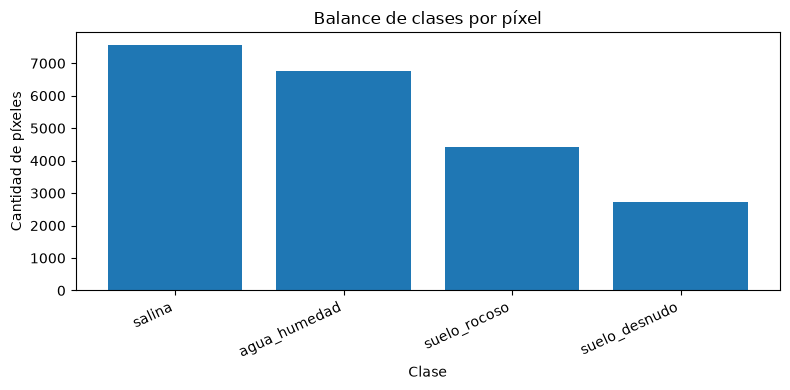

Chi-cuadrado balance uniforme: chi2=2730.16, p=0.000e+00


In [15]:
# 12. Balance de clases: PÍXELES vs sample_id
if "class_name" in df.columns:

    # Conteo por píxel.
    class_pixel = (
        df["class_name"]
        .value_counts()
        .rename_axis("class_name")
        .reset_index(name="pixel_count")
    )

    # Participación porcentual de cada clase.
    class_pixel["pixel_pct"] = (
        class_pixel["pixel_count"]
        / class_pixel["pixel_count"].sum()
        * 100
    )

    # Conteo por unidad independiente (sample_id/polígono).
    # Esta distinción es crucial porque un polígono grande aporta más píxeles.
    if "sample_id" in df.columns:
        class_sample = (
            df.drop_duplicates("sample_id")["class_name"]
            .value_counts()
            .rename_axis("class_name")
            .reset_index(name="sample_count")
        )

        class_balance = class_pixel.merge(
            class_sample,
            on="class_name",
            how="left",
        )
    else:
        class_balance = class_pixel

    display(class_balance)

    class_balance.to_sql(
        "quality_class_balance",
        engine,
        if_exists="replace",
        index=False,
    )

    # Visualización del balance por píxel.
    plt.figure(figsize=(8, 4))
    plt.bar(
        class_balance["class_name"].astype(str),
        class_balance["pixel_count"],
    )
    plt.title("Balance de clases por píxel")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad de píxeles")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

    # Test chi-cuadrado contra distribución uniforme.
    # H0: las 4 clases tienen la misma cantidad de píxeles.
    # IMPORTANTE: es un diagnóstico, NO un criterio automático de borrado.
    observed = class_pixel["pixel_count"].values
    expected = np.repeat(
        observed.sum() / len(observed),
        len(observed),
    )

    chi2, p = stats.chisquare(observed, expected)

    print(
        f"Chi-cuadrado balance uniforme: "
        f"chi2={chi2:.2f}, p={p:.3e}"
    )


### Interpretación del balance de clases

Por píxel:

- `salina`: 7.575 (**35,22%**);
- `agua_humedad`: 6.771 (**31,48%**);
- `suelo_rocoso`: 4.432 (**20,61%**);
- `suelo_desnudo`: 2.729 (**12,69%**).

Por `sample_id`, tres clases tienen 20 polígonos y `suelo_rocoso` tiene 10.

El test chi-cuadrado da `χ² = 2730,16` y `p ≈ 0`, por lo que se rechaza con enorme evidencia la hipótesis de que **los píxeles** estén uniformemente distribuidos entre las cuatro clases.

Pero hay dos advertencias:

1. los píxeles de un mismo `sample_id` no son observaciones independientes, por lo que el p-value clásico debe interpretarse con cautela;
2. que las clases no tengan igual número de píxeles **no implica** que debamos borrar datos. Polígonos de distinta superficie naturalmente producen distintos números de píxeles.

Para ML conviene evaluar métricas robustas al desbalance (`macro-F1`, balanced accuracy) y, si se balancea, hacerlo respetando `sample_id`.


In [16]:
# 13. Outliers UNIVARIADOS: IQR, z-score y MAD robusto
def outlier_report(
    data: pd.DataFrame,
    cols: list[str],
) -> pd.DataFrame:
    """
    Compara tres reglas de detección de extremos para cada variable:
    1) IQR/Tukey
    2) |z-score| > 3
    3) z-score modificado basado en MAD > 3.5

    Ninguna regla elimina filas automáticamente.
    """
    records = []

    for c in cols:
        # Fuerza valores numéricos, elimina infinitos y NaN.
        x = (
            pd.to_numeric(data[c], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        # Con muestras diminutas el análisis de outliers es poco estable.
        if len(x) < 10:
            continue

        # -------------------------
        # Método 1: IQR / regla de Tukey
        # -------------------------
        q1, q3 = x.quantile([.25, .75])
        iqr = q3 - q1
        lo_iqr = q1 - 1.5 * iqr
        hi_iqr = q3 + 1.5 * iqr

        # -------------------------
        # Método 2: z-score clásico
        # -------------------------
        z = np.abs(
            stats.zscore(x, nan_policy="omit")
        )

        # -------------------------
        # Método 3: MAD robusto
        # -------------------------
        med = x.median()
        mad = stats.median_abs_deviation(
            x,
            scale="normal",
        )

        # Si MAD=0 no puede dividirse; se devuelve 0 para todos.
        modified_z = (
            np.abs((x - med) / mad)
            if mad and mad > 0
            else pd.Series(
                np.zeros(len(x)),
                index=x.index,
            )
        )

        records.append({
            "variable": c,
            "n": int(len(x)),
            "iqr_low": float(lo_iqr),
            "iqr_high": float(hi_iqr),
            "out_iqr_n": int(
                ((x < lo_iqr) | (x > hi_iqr)).sum()
            ),
            "out_iqr_pct": float(
                ((x < lo_iqr) | (x > hi_iqr)).mean() * 100
            ),
            "out_z3_n": int((z > 3).sum()),
            "out_mad35_n": int((modified_z > 3.5).sum()),

            # Asimetría de la distribución.
            "skew": (
                float(stats.skew(x))
                if len(x) > 2
                else np.nan
            ),
        })

    return (
        pd.DataFrame(records)
        .sort_values("out_iqr_pct", ascending=False)
    )


outliers_uni = outlier_report(
    df,
    BANDAS + INDICES,
)

outliers_uni.to_sql(
    "quality_outliers_univariate",
    engine,
    if_exists="replace",
    index=False,
)

display(outliers_uni.head(30))


,variable,n,iqr_low,iqr_high,out_iqr_n,out_iqr_pct,out_z3_n,out_mad35_n,skew
0,B02,21507,-5131.000,15069.000,0,0.0,0,6714,-0.596864
1,B03,21507,-3899.000,14493.000,0,0.0,0,3144,-0.585259
2,B04,21507,-3305.500,14530.500,0,0.0,0,0,0.440636
3,B05,21507,-4387.250,15486.750,0,0.0,0,0,0.467062
4,B06,21507,-7995.625,17405.375,0,0.0,0,0,0.249356
5,B07,21507,-8252.500,17543.500,0,0.0,0,0,0.208911
6,B08,21507,-8335.750,17638.250,0,0.0,0,0,0.205692
7,B8A,21507,-8582.250,17467.750,0,0.0,0,0,0.164604
8,B11,21507,-3205.750,8212.250,0,0.0,0,0,-0.167937
9,B12,21507,-2189.125,6513.875,0,0.0,0,0,0.731517


### Interpretación de outliers univariados

La salida es deliberadamente interesante: con la regla IQR y con `|z| > 3` no se detectan outliers en las bandas, pero el método MAD marca **6.714 valores en B02** y **3.144 en B03**.

Esto no significa que haya miles de errores. Es una señal de que **el concepto de outlier depende del método y de la distribución**.

En este dataset se mezclan cuatro clases de cobertura con firmas espectrales muy distintas. Una distribución global puede ser multimodal; aplicar un único centro/MAD a todas las clases puede llamar “anómala” a una subpoblación perfectamente válida.

Mejora recomendada para un análisis científico: repetir IQR/MAD **por `class_name` y, si corresponde, por `sample_id`**, y luego revisar espacialmente los extremos antes de eliminarlos.


In [17]:
# 14. Outliers MULTIVARIADOS con Isolation Forest
features_for_outliers = [
    c for c in BANDAS + INDICES
    if c in df.columns
]

if len(features_for_outliers) >= 2:

    # Matriz numérica sin infinitos.
    X_out = (
        df[features_for_outliers]
        .replace([np.inf, -np.inf], np.nan)
    )

    # Imputación local por mediana sólo para que IsolationForest pueda operar.
    X_out = X_out.fillna(
        X_out.median(numeric_only=True)
    )

    # Escalado: aunque IsolationForest no depende estrictamente de distancias
    # euclídeas, estandarizar deja una representación homogénea y reutilizable.
    X_scaled = StandardScaler().fit_transform(X_out)

    # 300 árboles reducen variación Monte Carlo.
    # contamination="auto" deja que sklearn use su umbral automático.
    iso = IsolationForest(
        n_estimators=300,
        contamination="auto",
        random_state=RANDOM_STATE,
    )

    # fit_predict: +1 = normal; -1 = anomalía.
    score = iso.fit_predict(X_scaled)

    # Conservamos identificadores útiles para inspeccionar cada caso.
    df_outlier_flags = df[
        [
            c for c in ["sample_id", "class_name", "split"]
            if c in df.columns
        ]
    ].copy()

    df_outlier_flags["outlier_iso"] = score == -1

    # decision_function: valores más negativos = más anómalos.
    df_outlier_flags["outlier_score"] = (
        iso.decision_function(X_scaled)
    )

    print(
        df_outlier_flags["outlier_iso"]
        .value_counts()
    )

    # Se muestran los 20 casos con score más bajo.
    display(
        df_outlier_flags
        .sort_values("outlier_score")
        .head(20)
    )

    # Se guarda un FLAG: no se eliminan automáticamente esos registros.
    df_outlier_flags.to_csv(
        DATA_QUALITY / "outlier_flags_isolation_forest.csv",
        index=False,
    )

else:
    print(
        "No hay suficientes variables numéricas "
        "para outliers multivariados."
    )


outlier_iso
False    15622
True      5885
Name: count, dtype: int64


,sample_id,class_name,split,outlier_iso,outlier_score
18004,suelo_rocoso_002,suelo_rocoso,train,True,-0.174326
19760,suelo_rocoso_006,suelo_rocoso,train,True,-0.173901
19733,suelo_rocoso_006,suelo_rocoso,train,True,-0.172811
19734,suelo_rocoso_006,suelo_rocoso,train,True,-0.171896
19841,suelo_rocoso_006,suelo_rocoso,train,True,-0.171720
18353,suelo_rocoso_003,suelo_rocoso,train,True,-0.170202
18003,suelo_rocoso_002,suelo_rocoso,train,True,-0.169877
19708,suelo_rocoso_006,suelo_rocoso,train,True,-0.168902
20673,suelo_rocoso_008,suelo_rocoso,validation,True,-0.168758
19814,suelo_rocoso_006,suelo_rocoso,train,True,-0.168312


### Interpretación de Isolation Forest

`IsolationForest` marcó:

- **15.622** filas como normales;
- **5.885** como anomalías (~27,4%).

Los casos más extremos se concentran en varios `sample_id` de `suelo_rocoso` y algunos de `agua_humedad`.

Ese porcentaje es demasiado grande como para interpretar “anomalía” = “dato incorrecto”. Con `contamination="auto"`, el algoritmo aplica su umbral interno; además, una clase minoritaria o espectralmente distinta puede resultar fácil de aislar.

**Decisión metodológica correcta del notebook:** crear un flag y conservar las filas. Luego se puede preguntar:

- ¿los outliers se concentran por clase?
- ¿coinciden con bordes de polígonos?
- ¿son SCL problemáticos?
- ¿son verdaderas transiciones ambientales?

En teledetección, eliminar automáticamente extremos puede borrar justamente los casos más informativos.


,var_1,var_2,spearman_corr,abs_corr
45,B06,B07,0.999202,0.999202
56,B07,B08,0.997088,0.997088
46,B06,B08,0.996534,0.996534
57,B07,B8A,0.994754,0.994754
67,B08,B8A,0.992870,0.992870
47,B06,B8A,0.992503,0.992503
89,B11,B12,0.947117,0.947117
23,B04,B05,0.936447,0.936447
34,B05,B06,0.927669,0.927669
35,B05,B07,0.924436,0.924436


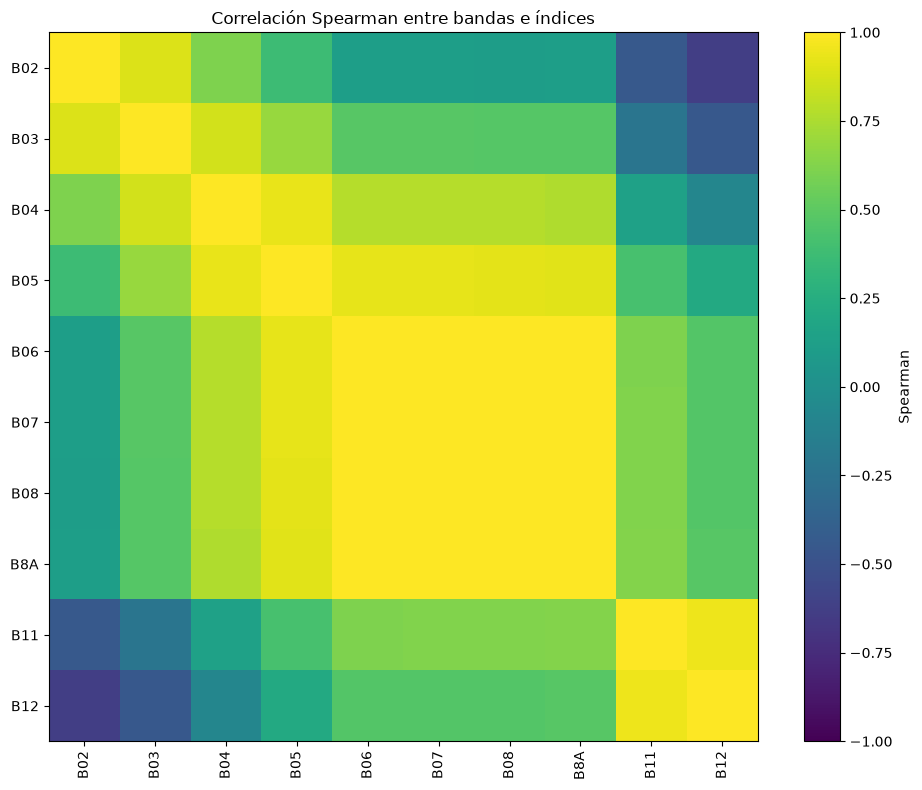

In [18]:
# 15. Redundancia: correlación alta entre predictoras
# Se analizan sólo bandas e índices candidatos.
feature_cols = [
    c for c in BANDAS + INDICES
    if c in df.columns
]

if len(feature_cols) >= 2:

    # Spearman usa rangos y capta relaciones monotónicas.
    # Es menos sensible a outliers/no normalidad que Pearson.
    corr = df[feature_cols].corr(method="spearman")

    # Para no repetir pares (A,B) y (B,A), se conserva sólo
    # el triángulo superior de la matriz.
    upper = corr.where(
        np.triu(
            np.ones(corr.shape),
            k=1,
        ).astype(bool)
    )

    # Se pasa de matriz a formato largo.
    high_corr_pairs = (
        upper.stack()
        .rename("spearman_corr")
        .reset_index()
        .rename(
            columns={
                "level_0": "var_1",
                "level_1": "var_2",
            }
        )
    )

    # Correlación absoluta permite ordenar por intensidad.
    high_corr_pairs["abs_corr"] = (
        high_corr_pairs["spearman_corr"].abs()
    )

    high_corr_pairs = high_corr_pairs.sort_values(
        "abs_corr",
        ascending=False,
    )

    display(high_corr_pairs.head(20))

    high_corr_pairs.to_sql(
        "quality_high_correlations",
        engine,
        if_exists="replace",
        index=False,
    )

    # Heatmap simple de correlaciones.
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, vmin=-1, vmax=1)
    plt.colorbar(label="Spearman")
    plt.xticks(
        range(len(feature_cols)),
        feature_cols,
        rotation=90,
    )
    plt.yticks(
        range(len(feature_cols)),
        feature_cols,
    )
    plt.title(
        "Correlación Spearman entre bandas e índices"
    )
    plt.tight_layout()
    plt.show()


### Interpretación de correlaciones

Hay redundancia espectral muy fuerte. Ejemplos:

- `B06–B07`: ρ ≈ **0,9992**;
- `B07–B08`: ρ ≈ **0,9971**;
- `B06–B08`: ρ ≈ **0,9965**;
- `B11–B12`: ρ ≈ **0,9471**.

Es esperable: bandas cercanas del espectro responden a procesos físicos relacionados.

Una correlación alta **no obliga** a eliminar una banda. Depende del modelo:

- regresiones/modelos lineales pueden sufrir multicolinealidad;
- Random Forest/Extra Trees toleran bastante redundancia;
- métodos de importancia pueden repartir importancia entre variables correlacionadas.

Aunque el título original mencionaba VIF, esta celda **calcula Spearman, no VIF**. Si se quiere VIF real, debe agregarse explícitamente con `statsmodels.stats.outliers_influence.variance_inflation_factor`.


In [19]:
# 16. Separabilidad ESTADÍSTICA por clase
def eta_squared_from_anova(
    groups: list[np.ndarray],
) -> float:
    """
    Calcula eta-cuadrado (η²), tamaño de efecto ANOVA.

    η² = variabilidad explicada por las diferencias entre clases
         / variabilidad total

    Cerca de 1 -> la variable separa fuertemente las clases.
    Cerca de 0 -> las medias de clase explican poco.
    """
    all_values = np.concatenate(groups)
    grand_mean = all_values.mean()

    # Suma de cuadrados ENTRE grupos.
    ss_between = sum(
        len(g) * (g.mean() - grand_mean) ** 2
        for g in groups
    )

    # Suma de cuadrados TOTAL.
    ss_total = (
        (all_values - grand_mean) ** 2
    ).sum()

    return (
        float(ss_between / ss_total)
        if ss_total > 0
        else np.nan
    )


separability_records = []

if "class_name" in df.columns:
    for c in feature_cols:

        # Se trabaja sólo con pares variable-clase válidos.
        temp = (
            df[[c, "class_name"]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        # Un vector de valores por clase.
        groups = [
            g[c].values
            for _, g in temp.groupby("class_name")
            if len(g) >= 3
        ]

        if len(groups) >= 2:
            # ANOVA paramétrico:
            # H0 = todas las medias de clase son iguales.
            f_stat, f_p = stats.f_oneway(*groups)

            # Kruskal-Wallis no paramétrico:
            # útil cuando no queremos asumir normalidad.
            h_stat, h_p = stats.kruskal(*groups)

            separability_records.append({
                "variable": c,
                "anova_f": float(f_stat),
                "anova_p": float(f_p),
                "kruskal_h": float(h_stat),
                "kruskal_p": float(h_p),
                "eta_squared": eta_squared_from_anova(groups),
                "n_classes": len(groups),
            })


# Ordenar por tamaño de efecto, más informativo que mirar sólo p-values.
separability = (
    pd.DataFrame(separability_records)
    .sort_values(
        "eta_squared",
        ascending=False,
    )
)

separability.to_sql(
    "statistics_class_separability",
    engine,
    if_exists="replace",
    index=False,
)

display(separability.head(25))


,variable,anova_f,anova_p,kruskal_h,kruskal_p,eta_squared,n_classes
7,B8A,445022.335611,0.0,19597.068347,0.0,0.984149,4
5,B07,393359.221084,0.0,19566.073921,0.0,0.982104,4
6,B08,367883.972624,0.0,19549.460582,0.0,0.980889,4
4,B06,360441.377458,0.0,19549.893876,0.0,0.980502,4
1,B03,147034.841666,0.0,17029.659222,0.0,0.953518,4
3,B05,145058.064310,0.0,17003.050207,0.0,0.952914,4
0,B02,121332.657748,0.0,14590.959913,0.0,0.944221,4
9,B12,114851.151685,0.0,19321.679005,0.0,0.941258,4
2,B04,112423.497528,0.0,17532.163804,0.0,0.940065,4
8,B11,85684.013774,0.0,16994.449951,0.0,0.922805,4


### Interpretación de separabilidad estadística

Todas las bandas separan fuertemente las cuatro clases:

- `B8A`: η² ≈ **0,984**;
- `B07`: η² ≈ **0,982**;
- `B08`: η² ≈ **0,981**;
- `B06`: η² ≈ **0,981**.

Un η² de 0,984 significa que, bajo esta descomposición univariada, aproximadamente el **98,4% de la variabilidad de B8A** queda asociada a diferencias entre las clases definidas.

ANOVA y Kruskal dan p-values prácticamente 0 en todas las bandas. Con 21.507 píxeles, los tests tienen enorme potencia; además, los píxeles dentro del mismo polígono no son independientes. Por eso conviene mirar más el **tamaño de efecto (η²)** y validar con splits agrupados que confiar sólo en significancia estadística.

La concordancia ANOVA + Kruskal fortalece la evidencia de diferencias de distribución entre clases, pero no reemplaza la validación fuera de muestra.


In [20]:
# 17. Información mutua y F-score para RANKING de variables
if "class_name" in df.columns and len(feature_cols) >= 2:

    # X: predictoras espectrales.
    X = (
        df[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
    )

    # Los estimadores sklearn no aceptan NaN en este contexto:
    # imputación por mediana sólo para ejecutar el ranking.
    X = X.fillna(
        X.median(numeric_only=True)
    )

    # y: etiqueta categórica.
    y = df["class_name"].astype(str)

    # Información mutua:
    # detecta dependencia general, incluso no lineal.
    # 0 ≈ poca información compartida; mayor = más información sobre y.
    mi = mutual_info_classif(
        X,
        y,
        random_state=RANDOM_STATE,
    )

    # f_classif:
    # F-test ANOVA univariado de cada predictor contra la clase.
    f_vals, p_vals = f_classif(X, y)

    ranking = pd.DataFrame({
        "variable": feature_cols,
        "mutual_info": mi,
        "f_score": f_vals,
        "f_pvalue": p_vals,
    }).sort_values(
        "mutual_info",
        ascending=False,
    )

    ranking.to_sql(
        "statistics_feature_ranking",
        engine,
        if_exists="replace",
        index=False,
    )

    display(ranking)


,variable,mutual_info,f_score,f_pvalue
7,B8A,1.265688,445022.335611,0.0
5,B07,1.258390,393359.221084,0.0
4,B06,1.248861,360441.377458,0.0
6,B08,1.245998,367883.972624,0.0
9,B12,1.176070,114851.151685,0.0
1,B03,0.900724,147034.841666,0.0
8,B11,0.888724,85684.013774,0.0
2,B04,0.874454,112423.497528,0.0
3,B05,0.867539,145058.064310,0.0
0,B02,0.762235,121332.657748,0.0


### Interpretación del ranking de variables

Por información mutua, las bandas con mayor relación con `class_name` son:

1. `B8A` ≈ **1,266**;
2. `B07` ≈ **1,258**;
3. `B06` ≈ **1,249**;
4. `B08` ≈ **1,246**.

`B02` queda última entre las diez, aunque sigue mostrando información considerable.

Información mutua y F-score miden cosas distintas:

- **MI** puede captar dependencias no lineales;
- **F-score** evalúa separabilidad basada en medias/varianza.

Este ranking es **univariado**: no dice qué combinación de variables será óptima en un modelo multivariado, especialmente cuando varias bandas están fuertemente correlacionadas.


# Parte E - Ingeniería geoespacial de datos

Aunque el práctico trabaja con tablas, las coordenadas pueden aportar información útil:

- patrones espaciales de clases;
- distancia al centroide general;
- densidad local aproximada;
- distancia a centroides por `sample_id`;
- indicadores de borde o aislamiento.

**Advertencia:** variables espaciales pueden mejorar desempeño pero también inducir sobreajuste local. Deben evaluarse con split por `sample_id` y, si es posible, con validación espacial.

In [21]:
# 18. Ingeniería de FEATURES espaciales desde x/y
def add_spatial_features(
    data: pd.DataFrame,
) -> pd.DataFrame:
    """
    Crea variables geométricas simples a partir de coordenadas x/y.

    ATENCIÓN:
    pueden mejorar un modelo si existe estructura espacial real,
    pero también producir fuga geográfica si la clase está asociada
    artificialmente a zonas específicas de entrenamiento.
    """
    out = data.copy()

    # Si no hay coordenadas, la función devuelve el dataset sin cambios.
    if not {"x", "y"}.issubset(out.columns):
        return out

    # Conversión robusta a numérico.
    x = pd.to_numeric(
        out["x"],
        errors="coerce",
    )
    y = pd.to_numeric(
        out["y"],
        errors="coerce",
    )

    # Coordenadas centradas respecto del promedio global.
    out["x_centered"] = x - x.mean()
    out["y_centered"] = y - y.mean()

    # Distancia euclídea al centroide global.
    out["dist_to_global_centroid"] = np.sqrt(
        out["x_centered"] ** 2
        + out["y_centered"] ** 2
    )

    # Ángulo polar respecto del centroide global, en radianes [-pi, pi].
    out["angle_to_global_centroid"] = np.arctan2(
        out["y_centered"],
        out["x_centered"],
    )

    if "sample_id" in out.columns:
        # Centroides de cada polígono/sample_id, repetidos por fila con transform.
        centroids = (
            out.groupby("sample_id")[["x", "y"]]
            .transform("mean")
        )

        # Distancia de cada píxel al centro de su propio polígono.
        out["dist_to_sample_centroid"] = np.sqrt(
            (x - centroids["x"]) ** 2
            + (y - centroids["y"]) ** 2
        )

    return out


df_spatial = add_spatial_features(df)

# Identificar sólo las columnas nuevas creadas.
new_spatial_cols = [
    c for c in df_spatial.columns
    if c not in df.columns
]

print(
    "Nuevas variables espaciales:",
    new_spatial_cols,
)

# Resumen estadístico para validar escalas y rangos.
display(
    df_spatial[new_spatial_cols].describe().T
    if new_spatial_cols
    else pd.DataFrame()
)


Nuevas variables espaciales: ['x_centered', 'y_centered', 'dist_to_global_centroid', 'angle_to_global_centroid', 'dist_to_sample_centroid']


,count,mean,std,min,25%,50%,75%,max
x_centered,21507.0,-1.039278e-11,6527.597014,-14328.903148,-3668.903148,-848.903148,3051.096852,13911.096852
y_centered,21507.0,-2.133983e-10,8423.548723,-18004.561306,-8984.561306,2075.438694,7915.438694,15015.438694
dist_to_global_centroid,21507.0,1.010077e+04,3396.391890,2326.554109,8511.719832,10482.936836,11630.132707,19584.030503
angle_to_global_centroid,21507.0,1.224507e-02,1.716072,-3.050115,-1.918957,0.672283,1.416325,3.130576
dist_to_sample_centroid,21507.0,2.082938e+02,139.723388,0.387439,108.822278,178.082983,268.120921,880.853595


### Interpretación de las features espaciales

Se agregaron cinco variables:

- `x_centered`, `y_centered`;
- `dist_to_global_centroid`;
- `angle_to_global_centroid`;
- `dist_to_sample_centroid`.

Las medias de `x_centered` y `y_centered` son prácticamente 0 (`~10⁻¹¹`), lo cual valida matemáticamente el centrado.

La distancia media al centroide global es de ~**10,1 km**, mientras que la distancia media al centroide del propio `sample_id` es ~**208 m**.

Estas variables pueden capturar estructura espacial, pero son peligrosas si las clases están geográficamente separadas en los polígonos de entrenamiento: el modelo podría aprender “dónde está” una clase en vez de “cómo se ve espectralmente”. Por eso se mantienen como **escenario opcional**.


In [22]:
# 19. Geometrías opcionales: áreas y perímetros desde GeoJSON
# Si existe labels/olaroz_training_polygons.geojson se calculan
# métricas geométricas por polígono.
try:
    import geopandas as gpd

    # Se prueban distintas ubicaciones locales.
    geo_candidates = [
        PROJECT_ROOT / "labels" / "olaroz_training_polygons.geojson",
        PROJECT_ROOT / "mentodatos_pdis" / "labels" / "olaroz_training_polygons.geojson",
        PROJECT_ROOT.parent / "mentodatos_pdis" / "labels" / "olaroz_training_polygons.geojson",
    ]

    geo_path = next(
        (p for p in geo_candidates if p.exists()),
        None,
    )

    if geo_path is not None:
        # GeoDataFrame: atributos + geometría.
        gdf = gpd.read_file(geo_path)
        print("GeoJSON:", geo_path, gdf.shape)

        # Sin CRS no se puede interpretar correctamente unidad/posición.
        if gdf.crs is None:
            print(
                "Advertencia: CRS ausente. "
                "Asignar CRS correcto antes de calcular áreas."
            )

        # Áreas/perímetros NO deben calcularse en lat/lon (grados).
        # Se proyecta a EPSG:32719 (UTM 19S), adecuado para el AOI de Olaroz.
        gdf_metric = (
            gdf.to_crs(32719)
            if gdf.crs is not None
            else gdf
        )

        # Área en m² y perímetro en m al trabajar en CRS métrico.
        gdf_metric["poly_area_m2"] = (
            gdf_metric.geometry.area
        )
        gdf_metric["poly_perimeter_m"] = (
            gdf_metric.geometry.length
        )

        # Compacidad = 4πA / P².
        # Un círculo ideal tiende a 1; formas irregulares dan valores menores.
        gdf_metric["poly_compactness"] = (
            4
            * np.pi
            * gdf_metric["poly_area_m2"]
            / (gdf_metric["poly_perimeter_m"] ** 2)
        )

        display(
            gdf_metric
            .drop(columns="geometry")
            .head()
        )

    else:
        print(
            "No se encontró GeoJSON local. "
            "Este bloque queda como plantilla opcional."
        )

except Exception as e:
    # Se mantiene opcional para que el resto del ETL pueda ejecutarse
    # aun si geopandas/GDAL no están disponibles.
    print(
        "Geometría opcional no disponible:",
        e,
    )


GeoJSON: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\labels\olaroz_training_polygons.geojson (70, 11)


,fid,sample_id,class_id,class_name,macro_class,season,confidence,split,source,notes,poly_area_m2,poly_perimeter_m,poly_compactness
0,1,agua_humedad_001,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,147995.267040,2074.081717,0.432321
1,2,agua_humedad_002,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,132063.765206,2206.931082,0.340734
2,3,agua_humedad_003,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,205342.684357,2764.921049,0.337539
3,4,agua_humedad_004,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,343844.932448,3193.496825,0.423682
4,5,agua_humedad_005,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,174737.430834,2009.104209,0.543990


### Interpretación de las geometrías

Se encontró el GeoJSON con **70 polígonos**, exactamente consistente con los 70 `sample_id` observados en la tabla.

Después de proyectar a **EPSG:32719 (UTM 19S)** se calculan:

- área en m²;
- perímetro en m;
- compacidad `4πA/P²`.

Por ejemplo, los primeros polígonos de `agua_humedad` tienen áreas del orden de 132.000–344.000 m².

La compacidad es adimensional: un círculo ideal se acerca a 1; valores menores indican formas más elongadas o irregulares. Puede utilizarse como feature a nivel polígono, pero primero habría que unirla con la tabla de píxeles mediante `sample_id` y validar que no introduzca leakage.


# Parte F - Transformación, curación y registro de decisiones

In [23]:
# 20. DECISION LOG: estructura profesional de curación
@dataclass
class Decision:
    """
    Representa una decisión de calidad/curación con evidencia y justificación.
    El objetivo es que la limpieza sea auditable y no una "caja negra".
    """
    issue: str
    evidence: str
    action: str
    justification: str
    affected_rows: int = 0
    affected_columns: str = ""


# Lista global de decisiones iniciales.
DECISIONS: list[Decision] = []


def add_decision(
    issue: str,
    evidence: str,
    action: str,
    justification: str,
    affected_rows: int = 0,
    affected_columns: str = "",
):
    """Agrega una decisión tipada al registro."""
    DECISIONS.append(
        Decision(
            issue,
            evidence,
            action,
            justification,
            affected_rows,
            affected_columns,
        )
    )


# -------------------------
# Reglas iniciales basadas en la auditoría
# -------------------------

# Missing values: no se imputa "por costumbre"; sólo si hay evidencia.
if df.isna().sum().sum() == 0:
    add_decision(
        "Valores faltantes",
        "0 celdas nulas",
        "No imputar",
        "No corresponde imputar donde no hay faltantes.",
    )
else:
    add_decision(
        "Valores faltantes",
        f"{int(df.isna().sum().sum())} celdas nulas",
        "Imputar numéricas con mediana y categoricas con moda",
        "Política reproducible y robusta para ML.",
        int(df.isna().sum().sum()),
    )

# Variables constantes: no aportan poder discriminante por sí solas.
constant_cols = [
    c for c in df.columns
    if df[c].nunique(dropna=False) <= 1
]
if constant_cols:
    add_decision(
        "Variables constantes",
        ", ".join(constant_cols),
        "Excluir como predictoras",
        "No aportan varianza al modelo.",
        affected_columns=", ".join(constant_cols),
    )

# Dependencia interna: varios píxeles vienen del mismo polígono.
if "sample_id" in df.columns:
    add_decision(
        "Fuga por dependencia entre píxeles",
        "Múltiples píxeles por sample_id",
        "Usar split agrupado por sample_id",
        "Evita que píxeles del mismo polígono caigan "
        "en train y test simultáneamente.",
        affected_columns="sample_id",
    )

# SCL se trata como variable de control de calidad,
# no como predictor físico principal de cobertura.
if "scl" in df.columns:
    add_decision(
        "Variable SCL",
        "Control de calidad Sentinel-2",
        "Mantener como control, no como predictor principal",
        "Puede representar el filtro de extracción "
        "y no una propiedad física de la cobertura.",
        affected_columns="scl",
    )

# Vista del registro hasta este punto.
pd.DataFrame([
    asdict(d)
    for d in DECISIONS
])


,issue,evidence,action,justification,affected_rows,affected_columns
0,Valores faltantes,0 celdas nulas,No imputar,No corresponde imputar donde no hay faltantes.,0,
1,Variables constantes,"season, confidence, source",Excluir como predictoras,No aportan varianza al modelo.,0,"season, confidence, source"
2,Fuga por dependencia entre píxeles,Múltiples píxeles por sample_id,Usar split agrupado por sample_id,Evita que píxeles del mismo polígono caigan en...,0,sample_id
3,Variable SCL,Control de calidad Sentinel-2,"Mantener como control, no como predictor princ...",Puede representar el filtro de extracción y no...,0,scl


### Interpretación del `Decision Log`

El registro inicial documenta cuatro decisiones:

1. **faltantes:** no imputar porque hay 0;
2. **variables constantes:** excluir `season`, `confidence`, `source` como predictoras;
3. **dependencia entre píxeles:** dividir por `sample_id`;
4. **SCL:** conservar como control, no como predictor espectral principal.

Esta bitácora es una pieza central de una curación profesional: una transformación sin evidencia y sin justificación es difícil de auditar o reproducir.


In [24]:
# 21. Función de CURACIÓN reproducible
def curate_dataset(
    data: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Aplica de manera determinista la política de curación y devuelve:
    1) dataset curado;
    2) decisiones tomadas durante esta ejecución.
    """

    # Copia defensiva: no alterar la entrada.
    curated = data.copy()
    local_decisions = []

    # --------------------------------------------------------
    # 1) Normalización de nombres de columnas
    # --------------------------------------------------------
    original_cols = curated.columns.tolist()
    curated.columns = [
        normalize_colname(c)
        for c in curated.columns
    ]

    if curated.columns.tolist() != original_cols:
        local_decisions.append(
            Decision(
                "Nombres de columnas",
                "Columnas con espacios o símbolos",
                "Normalizar a snake_case",
                "Facilita SQL y reproducibilidad.",
            )
        )

    # --------------------------------------------------------
    # 2) Infinitos -> NaN
    # --------------------------------------------------------
    num_cols = (
        curated
        .select_dtypes(include=[np.number])
        .columns
        .tolist()
    )

    inf_mask = (
        np.isinf(curated[num_cols]).sum().sum()
        if num_cols
        else 0
    )

    if inf_mask:
        curated[num_cols] = curated[num_cols].replace(
            [np.inf, -np.inf],
            np.nan,
        )

        local_decisions.append(
            Decision(
                "Infinitos",
                f"{inf_mask} infinitos",
                "Reemplazar por NaN",
                "Los infinitos rompen modelos y estadísticas.",
                int(inf_mask),
            )
        )

    # --------------------------------------------------------
    # 3) Duplicados exactos
    # --------------------------------------------------------
    before = len(curated)

    curated = (
        curated
        .drop_duplicates()
        .reset_index(drop=True)
    )

    removed = before - len(curated)

    if removed:
        local_decisions.append(
            Decision(
                "Duplicados exactos",
                f"{removed} filas",
                "Eliminar duplicados exactos",
                "No agregan información y sesgan frecuencias.",
                removed,
            )
        )

    # --------------------------------------------------------
    # 4) Limpieza de texto categórico
    # --------------------------------------------------------
    # Sólo strip: elimina espacios externos, pero conserva capitalización.
    for c in curated.select_dtypes(
        exclude=[np.number]
    ).columns:
        curated[c] = (
            curated[c]
            .astype("string")
            .str.strip()
        )

    local_decisions.append(
        Decision(
            "Categorías textuales",
            "Posibles espacios invisibles",
            "Aplicar strip a strings",
            "Evita categorías duplicadas por formato.",
        )
    )

    # --------------------------------------------------------
    # 5) Imputación simple SÓLO si existen nulos
    # --------------------------------------------------------
    missing_total = int(
        curated.isna().sum().sum()
    )

    if missing_total:
        for c in curated.columns:
            if curated[c].isna().any():

                # Numéricas -> mediana: robusta frente a extremos.
                if pd.api.types.is_numeric_dtype(
                    curated[c]
                ):
                    curated[c] = curated[c].fillna(
                        curated[c].median()
                    )

                # Categóricas -> moda; si no existe moda, "desconocido".
                else:
                    mode = curated[c].mode(
                        dropna=True
                    )
                    fill_value = (
                        mode.iloc[0]
                        if len(mode)
                        else "desconocido"
                    )
                    curated[c] = (
                        curated[c]
                        .fillna(fill_value)
                    )

        local_decisions.append(
            Decision(
                "Imputación",
                f"{missing_total} celdas nulas",
                "Mediana/moda",
                "Estrategia simple, documentada y reproducible.",
                missing_total,
            )
        )

    # --------------------------------------------------------
    # 6) Ingeniería geoespacial
    # --------------------------------------------------------
    curated = add_spatial_features(curated)

    spatial_added = [
        c for c in curated.columns
        if c not in data.columns
    ]

    if spatial_added:
        local_decisions.append(
            Decision(
                "Ingeniería geoespacial",
                ", ".join(spatial_added),
                "Crear variables derivadas de x/y",
                "Permite modelar patrones espaciales "
                "con validación cuidadosa.",
                affected_columns=", ".join(spatial_added),
            )
        )

    # --------------------------------------------------------
    # 7) Flag de outlier multivariado
    # --------------------------------------------------------
    feature_cols_local = [
        c for c in [*BANDAS, *INDICES]
        if c in curated.columns
    ]

    if len(feature_cols_local) >= 2:
        X = (
            curated[feature_cols_local]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(
                curated[feature_cols_local]
                .median(numeric_only=True)
            )
        )

        Xs = StandardScaler().fit_transform(X)

        # Aquí se usan 200 árboles (antes se usaron 300 para diagnóstico).
        # Por eso el número exacto de flags puede variar ligeramente entre bloques.
        iso = IsolationForest(
            n_estimators=200,
            random_state=RANDOM_STATE,
            contamination="auto",
        )

        curated["flag_outlier_iso"] = (
            iso.fit_predict(Xs) == -1
        )

        local_decisions.append(
            Decision(
                "Outliers multivariados",
                "IsolationForest",
                "Crear flag, no eliminar automáticamente",
                "En salares los extremos pueden ser "
                "ambientalmente válidos.",
                int(curated["flag_outlier_iso"].sum()),
                "flag_outlier_iso",
            )
        )

    # --------------------------------------------------------
    # 8) Metadatos de curación
    # --------------------------------------------------------
    # Permiten saber cuándo y con qué run se produjo cada fila.
    curated["_curated_at_utc"] = (
        datetime.utcnow()
        .isoformat(timespec="seconds")
    )

    curated["_curation_run_id"] = (
        run_metadata["run_id"]
    )

    return (
        curated,
        pd.DataFrame([
            asdict(d)
            for d in local_decisions
        ]),
    )


# Ejecutar curación.
curated, decisions_auto = curate_dataset(df)

# Unir decisiones previas de auditoría + decisiones de transformación.
all_decisions = pd.concat(
    [
        pd.DataFrame([
            asdict(d)
            for d in DECISIONS
        ]),
        decisions_auto,
    ],
    ignore_index=True,
)

display(all_decisions)

# Comparación estructural antes/después.
print("Shape original:", df.shape)
print("Shape curado:", curated.shape)


,issue,evidence,action,justification,affected_rows,affected_columns
0,Valores faltantes,0 celdas nulas,No imputar,No corresponde imputar donde no hay faltantes.,0,
1,Variables constantes,"season, confidence, source",Excluir como predictoras,No aportan varianza al modelo.,0,"season, confidence, source"
2,Fuga por dependencia entre píxeles,Múltiples píxeles por sample_id,Usar split agrupado por sample_id,Evita que píxeles del mismo polígono caigan en...,0,sample_id
3,Variable SCL,Control de calidad Sentinel-2,"Mantener como control, no como predictor princ...",Puede representar el filtro de extracción y no...,0,scl
4,Categorías textuales,Posibles espacios invisibles,Aplicar strip a strings,Evita categorías duplicadas por formato.,0,
5,Ingeniería geoespacial,"x_centered, y_centered, dist_to_global_centroi...",Crear variables derivadas de x/y,Permite modelar patrones espaciales con valida...,0,"x_centered, y_centered, dist_to_global_centroi..."
6,Outliers multivariados,IsolationForest,"Crear flag, no eliminar automáticamente",En salares los extremos pueden ser ambientalme...,5855,flag_outlier_iso


Shape original: (21507, 22)
Shape curado: (21507, 30)


### Interpretación de la curación reproducible

El dataset pasa de **(21.507, 22)** a **(21.507, 30)**:

- no se eliminó ninguna fila;
- se agregaron 8 columnas.

Las 8 nuevas columnas corresponden a:

- 5 features espaciales;
- `flag_outlier_iso`;
- `_curated_at_utc`;
- `_curation_run_id`.

El segundo `IsolationForest` marca **5.855** filas, mientras que el bloque diagnóstico anterior marcó 5.885. La diferencia se explica porque aquí se usan **200 árboles** y antes 300; aun con la misma semilla, la configuración del ensemble cambia ligeramente el límite de anomalía.

Lo importante es que ninguna de esas 5.855 filas se borra automáticamente. El flag queda disponible para análisis posterior.


In [25]:
# 22. Persistencia de resultados curados
# Rutas de artefactos.
curated_csv = (
    DATA_PROCESSED
    / "olaroz_samples_curated_practico2.csv"
)
curated_parquet = (
    DATA_PROCESSED
    / "olaroz_samples_curated_practico2.parquet"
)
decision_csv = (
    DATA_QUALITY
    / "decision_log_practico2.csv"
)

# CSV: interoperable y fácil de inspeccionar.
curated.to_csv(
    curated_csv,
    index=False,
)

# Parquet: columnar, compacto y conserva mejor los tipos.
# Si pyarrow/fastparquet no está instalado, el pipeline continúa.
try:
    curated.to_parquet(
        curated_parquet,
        index=False,
    )
except Exception as e:
    print(
        "No se pudo guardar parquet:",
        e,
    )

# Registro de decisiones como archivo independiente.
all_decisions.to_csv(
    decision_csv,
    index=False,
)

# Capa MART: dataset final curado para consumo analítico/ML.
curated.to_sql(
    "mart_olaroz_samples_curated",
    engine,
    if_exists="replace",
    index=False,
)

# También se persiste la bitácora dentro del warehouse.
all_decisions.to_sql(
    "curation_decision_log",
    engine,
    if_exists="replace",
    index=False,
)

print("CSV curado:", curated_csv)
print("Decision log:", decision_csv)
print("SQLite:", DB_PATH)


CSV curado: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\data\processed\olaroz_samples_curated_practico2.csv
Decision log: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\data\quality\decision_log_practico2.csv
SQLite: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\data\warehouse\m10_practico2_etl.sqlite


### Interpretación de la persistencia

Se escriben tres tipos de salida:

- **CSV/Parquet:** intercambio y análisis;
- **SQLite `mart_olaroz_samples_curated`:** consumo estructurado;
- **decision log:** trazabilidad.

Esta separación reproduce una arquitectura ETL simple:

`fuente → staging → quality/statistics → curación → mart`.

Si Parquet falla por falta de `pyarrow`, el notebook continúa y conserva CSV + SQLite.


# Parte G - Dataset listo para Machine Learning

Una curación útil termina con un objeto que puede conectarse a un pipeline de ML sin repetir decisiones manuales.

In [26]:
# 23. Construcción de matriz X/y SIN fuga de información
# Variable objetivo.
LABEL_COL = (
    "class_name"
    if "class_name" in curated.columns
    else None
)
# Variables que no deben entrar como predictoras en el escenario base.
# Motivos:
# - class_* y macro_class: contienen directamente la etiqueta.
# - sample_id: identificador, puede memorizar polígonos.
# - split: codifica partición experimental.
# - source/notes/season/confidence: metadatos, no señal espectral principal.
# - campos de curación: linaje técnico.
LEAKAGE_COLS = [
    c for c in [
        "class_id",
        "class_name",
        "macro_class",
        "sample_id",
        "split",
        "source",
        "notes",
        "season",
        "confidence",
        "_curated_at_utc",
        "_curation_run_id",
    ]
    if c in curated.columns
]

# Universo de columnas que queda tras excluir metadatos/etiquetas.
candidate_features = [
    c for c in curated.columns
    if c not in LEAKAGE_COLS
]

# Escenario A: sólo señal espectral.
spectral_features = [
    c for c in BANDAS + INDICES
    if c in candidate_features
]

# Escenario B opcional: señal espacial.
# Debe evaluarse con validación geográfica porque puede generar leakage espacial.
spatial_model_features = [
    c for c in [
        "x_centered",
        "y_centered",
        "dist_to_global_centroid",
        "angle_to_global_centroid",
        "dist_to_sample_centroid",
    ]
    if c in candidate_features
]

print(
    "Variables excluidas por fuga/metadatos:",
    LEAKAGE_COLS,
)
print(
    "Features espectrales:",
    spectral_features,
)
print(
    "Features espaciales opcionales:",
    spatial_model_features,
)

# Matriz predictora y vector objetivo del escenario base.
X = curated[spectral_features].copy()
y = (
    curated[LABEL_COL].astype(str)
    if LABEL_COL
    else None
)


Variables excluidas por fuga/metadatos: ['class_id', 'class_name', 'macro_class', 'sample_id', 'split', 'source', 'notes', 'season', 'confidence', '_curated_at_utc', '_curation_run_id']
Features espectrales: ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']
Features espaciales opcionales: ['x_centered', 'y_centered', 'dist_to_global_centroid', 'angle_to_global_centroid', 'dist_to_sample_centroid']


### Interpretación de X/y y fuga de información

El escenario base usa exactamente **10 bandas espectrales** como `X`.

Se excluyen etiquetas, identificadores, split y metadatos para evitar que el modelo reciba información que no estaría disponible o que revelaría indirectamente la respuesta.

En `pixels_raw` todavía no hay índices derivados, por eso `spectral_features` contiene sólo `B02…B12`.

Las cinco variables espaciales aparecen listadas como **opcionales**, pero no entran en `X` en este escenario base. Esto permite comparar en el Práctico 3:

- modelo espectral puro;
- modelo espectral + espacial;
- validación espacial/por grupos.


In [27]:
# 24. Pipeline sklearn reproducible de PREPROCESAMIENTO
# En este escenario todas las features de X son numéricas.
numeric_features = X.columns.tolist()

# ColumnTransformer permite definir transformaciones por grupo de columnas.
preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    # Si en otro run aparecen faltantes:
                    # imputar mediana dentro del pipeline evita hacerlo "a mano".
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        ),
                    ),

                    # Media 0, desviación 1.
                    # Importante para muchos modelos y comparabilidad de escalas.
                    (
                        "scaler",
                        StandardScaler(),
                    ),
                ]
            ),
            numeric_features,
        ),
    ],

    # Cualquier columna no declarada se elimina.
    remainder="drop",
)

# Pipeline externo preparado para conectar después un clasificador:
# Pipeline([preprocess, model]).
preprocess_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
    ]
)

# fit aprende mediana/media/std; transform aplica exactamente lo aprendido.
Xt = preprocess_pipeline.fit_transform(X)

print(
    "Matriz transformada:",
    Xt.shape,
)


Matriz transformada: (21507, 10)


### Interpretación del pipeline de preprocesamiento

La salida `Matriz transformada: (21507, 10)` confirma que:

- no se perdieron filas;
- siguen existiendo 10 predictores;
- cada predictor pasó por imputación de mediana + estandarización.

Como actualmente no hay NaN, el imputador no cambia valores. `StandardScaler` sí transforma las bandas a una escala comparable.

**Detalle metodológico importante para ML:** en una evaluación final, el `fit` del preprocesamiento debería hacerse **sólo con train**, no sobre todo el dataset antes del split. La forma más segura es construir un único `Pipeline([preprocess, classifier])` y evaluarlo con el split/cross-validation agrupado. En este notebook esta transformación se muestra didácticamente antes del modelado.


In [28]:
# 25. Split AGRUPADO por sample_id para evitar fuga
if y is not None and "sample_id" in curated.columns:

    # Cada sample_id representa un grupo de píxeles provenientes
    # del mismo polígono/muestra.
    groups = curated["sample_id"].astype(str)

    # 80/20 aproximado, pero respetando grupos completos.
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    # Se obtienen índices, no DataFrames todavía.
    train_idx, test_idx = next(
        splitter.split(
            X,
            y,
            groups=groups,
        )
    )

    print(
        "Train:",
        len(train_idx),
        "Test:",
        len(test_idx),
    )

    # Control crítico: debe ser CERO.
    # Si fuera >0, habría fuga entre entrenamiento y prueba.
    shared_groups = set(
        groups.iloc[train_idx]
    ).intersection(
        set(groups.iloc[test_idx])
    )

    print(
        "Sample_id compartidos:",
        len(shared_groups),
    )

else:
    print(
        "No hay sample_id o etiqueta "
        "para split agrupado."
    )


Train: 16478 Test: 5029
Sample_id compartidos: 0


### Interpretación del split por grupos

Resultado:

- train: **16.478 píxeles**;
- test: **5.029 píxeles**;
- `sample_id` compartidos: **0**.

El 20% solicitado se aplica sobre **grupos**, no sobre filas individuales. Como los `sample_id` tienen distintos tamaños, la proporción final por píxel no tiene por qué ser exactamente 80/20.

El valor crítico es `Sample_id compartidos: 0`: prueba que ningún polígono aporta píxeles simultáneamente a train y test. Esto evita una fuente de fuga especialmente grave en datos geoespaciales.


In [29]:
# 26. Data Quality Score SINTÉTICO
def quality_score(
    data: pd.DataFrame,
) -> pd.DataFrame:
    """
    Heurística didáctica 0..100 basada en cuatro penalizaciones.

    NO es una métrica estadística estándar ni debe usarse como verdad absoluta.
    Sirve como resumen operativo y debe interpretarse junto a los controles.
    """
    num = data.select_dtypes(
        include=[np.number]
    )

    # Máximo 40 puntos de penalización por faltantes.
    missing_penalty = min(
        40,
        data.isna().mean().mean() * 100,
    )

    # Máximo 20 por duplicados.
    dup_penalty = min(
        20,
        data.duplicated().mean() * 100,
    )

    # Máximo 20 por infinitos numéricos.
    inf_penalty = min(
        20,
        (
            np.isinf(num).sum().sum()
            / max(num.size, 1)
            * 100
        )
        if num.size
        else 0,
    )

    # Máximo 20 según proporción de columnas constantes.
    constant_penalty = min(
        20,
        (
            sum(
                data[c].nunique(dropna=False) <= 1
                for c in data.columns
            )
            / max(data.shape[1], 1)
            * 100
        ),
    )

    score = (
        100
        - missing_penalty
        - dup_penalty
        - inf_penalty
        - constant_penalty
    )

    return pd.DataFrame([{
        "score_0_100": round(score, 2),
        "missing_penalty": round(
            missing_penalty,
            2,
        ),
        "duplicate_penalty": round(
            dup_penalty,
            2,
        ),
        "infinite_penalty": round(
            inf_penalty,
            2,
        ),
        "constant_penalty": round(
            constant_penalty,
            2,
        ),
    }])


# Comparación antes/después.
score_before = (
    quality_score(df)
    .assign(stage="before")
)

score_after = (
    quality_score(curated)
    .assign(stage="after")
)

quality_scores = pd.concat(
    [score_before, score_after],
    ignore_index=True,
)

quality_scores.to_sql(
    "quality_score_summary",
    engine,
    if_exists="replace",
    index=False,
)

display(quality_scores)


,score_0_100,missing_penalty,duplicate_penalty,infinite_penalty,constant_penalty,stage
0,86.36,0.0,0.0,0.0,13.64,before
1,83.33,0.0,0.0,0.0,16.67,after


### Interpretación crítica del `Data Quality Score`

La salida parece paradójica:

- **before:** 86,36;
- **after:** 83,33.

La curación no empeoró los datos. El score baja porque su fórmula penaliza la **proporción de columnas constantes**:

- antes: 3 constantes / 22 columnas = **13,64%** de penalización;
- después: aparecen dos metadatos constantes del run (`_curated_at_utc`, `_curation_run_id`), dando 5 / 30 = **16,67%**.

Esto demuestra por qué el score está etiquetado como **heurística didáctica** y no como métrica estándar. Un buen score de calidad debería:

- excluir columnas técnicas de linaje;
- ponderar dimensiones según criticidad;
- distinguir calidad de datos de utilidad predictiva;
- medir cumplimiento del contrato, no simplemente contar constantes.


# Parte H - Reporte automático final

In [30]:
# 27. Generación automática de REPORTE Markdown
# Markdown es fácil de versionar en Git y convertir luego a HTML/PDF.
report_md = (
    REPORTS
    / "reporte_curacion_practico2.md"
)

with open(
    report_md,
    "w",
    encoding="utf-8",
) as f:

    # Encabezado.
    f.write(
        "# Reporte de curación - Práctico 2 M10\n\n"
    )

    # Linaje del pipeline.
    f.write(
        f"Run ID: `{run_metadata['run_id']}`\n\n"
    )

    # Dimensiones antes/después.
    f.write("## Dataset\n\n")
    f.write(
        f"- Filas originales: {df.shape[0]:,}\n"
    )
    f.write(
        f"- Columnas originales: {df.shape[1]:,}\n"
    )
    f.write(
        f"- Filas curadas: {curated.shape[0]:,}\n"
    )
    f.write(
        f"- Columnas curadas: {curated.shape[1]:,}\n\n"
    )

    # Tablas convertidas a Markdown.
    # Requiere la dependencia 'tabulate'.
    f.write("## Integridad\n\n")
    f.write(
        integrity.to_markdown(index=False)
    )

    f.write("\n\n## Decisiones\n\n")
    f.write(
        all_decisions.to_markdown(index=False)
    )

    # Referencias a artefactos generados.
    f.write("\n\n## Salidas\n\n")
    f.write(
        f"- CSV curado: `{curated_csv}`\n"
    )
    f.write(
        f"- SQLite ETL: `{DB_PATH}`\n"
    )
    f.write(
        f"- Decision log: `{decision_csv}`\n"
    )

print(report_md)


C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\reports\reporte_curacion_practico2.md


### Interpretación del reporte final

La última celda convierte resultados del pipeline en un archivo Markdown versionable.

Incluye:

- `run_id`;
- dimensiones originales/curadas;
- tabla de integridad;
- bitácora de decisiones;
- rutas a CSV, SQLite y decision log.

La ruta impresa confirma que el archivo fue generado correctamente en el entorno de la ejecución almacenada.

Si aparece `ModuleNotFoundError: No module named 'tabulate'`, la causa es `DataFrame.to_markdown()`. Se resuelve instalando `tabulate` (`python -m pip install tabulate` o `%pip install tabulate`).


# Entregables sugeridos del grupo

1. `notebook_practico2_grupo_N.ipynb`: notebook ejecutable de punta a punta.
2. `data/processed/olaroz_samples_curated_grupo_N.csv`: dataset curado.
3. `data/warehouse/m10_practico2_etl.sqlite`: base reproducible con staging, quality y mart.
4. `data/quality/decision_log_practico2.csv`: bitácora de decisiones.
5. `reports/reporte_curacion_practico2.md`: informe técnico breve.

Una buena entrega no sólo muestra gráficos: **demuestra que el dataset quedó listo para modelar sin fuga, sin ambigüedad y con decisiones defendibles**.